# Model evaluation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

checkpoint_path = Path("checkpoints/best_model.pt")
checkpoint = torch.load(checkpoint_path, map_location="cpu")
history = checkpoint["history"]

print(f"Best epoch: {checkpoint['best_epoch']}")
print(f"Best validation MAE: {checkpoint['best_val_mae']:.6f}")
print("Test metrics:", checkpoint["test_metrics"])

Best epoch: 133
Best validation MAE: 0.069420
Test metrics: {'mse': 0.010969750536978245, 'mae': 0.06893672256469727}


## MAE loss curve

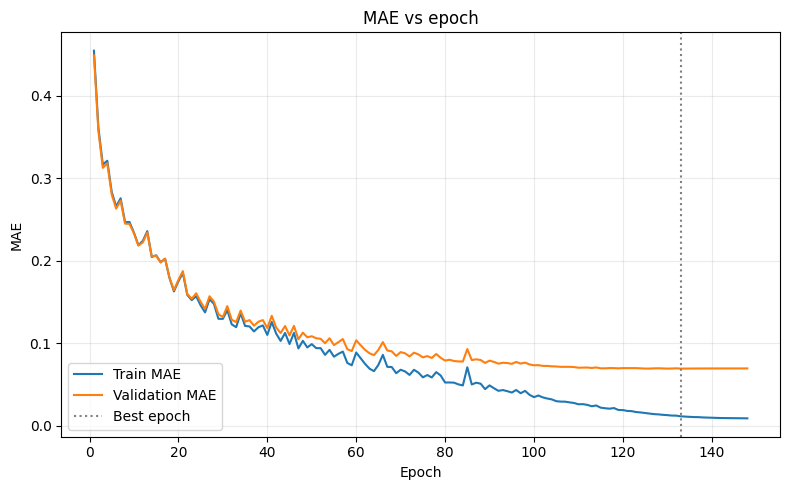

In [2]:
epochs = [row["epoch"] for row in history]
train_mae = [row["train_mae"] for row in history]
val_mae = [row["val_mae"] for row in history]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_mae, label="Train MAE")
ax.plot(epochs, val_mae, label="Validation MAE")
ax.axvline(checkpoint["best_epoch"], color="0.5", linestyle=":", label="Best epoch")
ax.set(xlabel="Epoch", ylabel="MAE", title="MAE vs epoch")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

## Predictions on test set

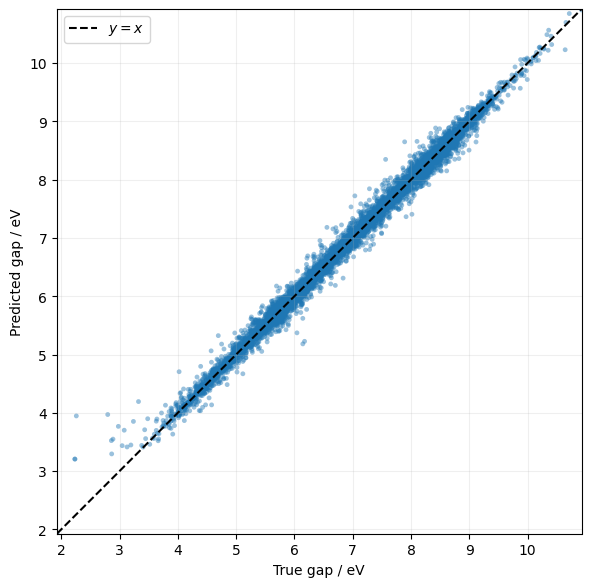

In [5]:
true = checkpoint["test_targets"].numpy()
predicted = checkpoint["test_predictions"].numpy()
limits = [min(true.min(), predicted.min()), max(true.max(), predicted.max())]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true, predicted, s=12, alpha=0.45, edgecolors="none")
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1.5, label=r"$y=x$")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_aspect("equal", adjustable="box")
ax.set(xlabel="True gap / eV", ylabel="Predicted gap / eV")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()